# Installations


In [ ]:
!pip install diffusers transformers accelerate safetensors insightface onnxruntime-gpu
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 6.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.0/277.0 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 87.3 MB/s eta 0:00:00
  Created wheel for insightface: filename=insightface-0.7.3-cp312-cp312-linux_x86_64.whl size=1071488 sha256=62c5826683112843234fccf9fd3f97f35f501f7bdda1a6b13ed528f8aea30820
  Stored in directory: /root/.cache/pip/wheels/73/3c/e2/6d4815e8a8b33a2006554d65ce0d1f973e768f4c7a222fa675
Successfully built insightface
Looking in indexes: https://download.pytorch.org/whl/cu121


# Imports

In [ ]:
import torch
import numpy as np
from diffusers import StableDiffusionImg2ImgPipeline, StableDiffusionInpaintPipeline
from PIL import Image, ImageFilter
import matplotlib.pyplot as plt
from google.colab import files

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


# Loading the Pretrained Models

In [ ]:
model_id = "Lykon/dreamshaper"

img2img_pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)
img2img_pipe = img2img_pipe.to("cuda")
img2img_pipe.safety_checker = None

inpaint_pipe = StableDiffusionInpaintPipeline.from_pretrained(
    "runwayml/stable-diffusion-inpainting",
    torch_dtype=torch.float16
)
inpaint_pipe = inpaint_pipe.to("cuda")
inpaint_pipe.safety_checker = None

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--Lykon--dreamshaper/snapshots/228d79cb20811466f5c5710aa91f05dabd0b8a14/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--Lykon--dreamshaper/snapshots/228d79cb20811466f5c5710aa91f05dabd0b8a14/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


...

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


# Face Detection and Masking

In [ ]:
import cv2

def detect_face_mask(image: Image.Image, padding: int = 40) -> Image.Image:
    """
    Returns a binary PIL mask where:
      - WHITE (255) = face region (PROTECTED — do not change)
      - BLACK (0)   = body region (FREE to transform)
    """
    img_cv = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)
    gray   = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)

    detector = cv2.CascadeClassifier(
        cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    )
    faces = detector.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

    mask = Image.new("L", image.size, 0)
    mask_arr = np.array(mask)

    for (x, y, w, h) in faces:
        x1 = max(0, x - padding)
        y1 = max(0, y - padding)
        x2 = min(image.width,  x + w + padding)
        y2 = min(image.height, y + h + padding)
        mask_arr[y1:y2, x1:x2] = 255

    return Image.fromarray(mask_arr)

def create_body_inpaint_mask(face_mask: Image.Image) -> Image.Image:
    """
    Inverts the face mask so the inpainter only touches the body.
    Also adds a feathered edge to avoid hard seams.
    """
    body_mask = Image.fromarray(255 - np.array(face_mask))
    body_mask = body_mask.filter(ImageFilter.GaussianBlur(radius=8))
    return body_mask

def paste_original_face(original: Image.Image,
                        transformed: Image.Image,
                        face_mask: Image.Image,
                        blend_radius: int = 12) -> Image.Image:
    """
    Hard-pastes the original face region onto the transformed image,
    with a Gaussian-blurred edge for a seamless blend.
    """
    soft_mask = face_mask.filter(ImageFilter.GaussianBlur(radius=blend_radius))
    soft_mask = soft_mask.convert("L")

    result = Image.composite(original, transformed, soft_mask)
    return result

# Prompts

In [ ]:
BODY_PROMPT = """
athletic male physique, muscular body, defined abs, broad shoulders,
lean greek god aesthetic, fitness model, studio lighting,
realistic skin texture, detailed muscles, natural proportion, no tattoos
"""

BODY_NEGATIVE = """
face change, identity change, different person, altered facial structure,
bad anatomy, extra limbs, distorted body, deformed muscles,
cartoon, anime, low quality, plastic skin, blurry
"""

In [ ]:
def transform_physique(image_path: str,
                       strength: float = 0.60,
                       guidance_scale: float = 7.5,
                       steps: int = 40,
                       use_inpaint: bool = True) -> dict:

    init_image = Image.open(image_path).convert("RGB").resize((512, 512))
    face_mask  = detect_face_mask(init_image, padding=40)
    body_mask  = create_body_inpaint_mask(face_mask)
    if use_inpaint:
        transformed = inpaint_pipe(
            prompt          = BODY_PROMPT,
            negative_prompt = BODY_NEGATIVE,
            image           = init_image,
            mask_image      = body_mask,
            strength        = strength,
            guidance_scale  = guidance_scale,
            num_inference_steps = steps,
        ).images[0]
    else:
        transformed = img2img_pipe(
            prompt          = BODY_PROMPT,
            negative_prompt = BODY_NEGATIVE,
            image           = init_image,
            strength        = 0.40,
            guidance_scale  = guidance_scale,
            num_inference_steps = steps,
        ).images[0]
    final = paste_original_face(init_image, transformed, face_mask, blend_radius=12)
    return {
        "original"   : init_image,
        "face_mask"  : face_mask,
        "body_mask"  : body_mask,
        "transformed": transformed,
        "final"      : final,
    }

Saving download (2).jpg to download (2) (3).jpg


  0%|          | 0/24 [00:00<?, ?it/s]

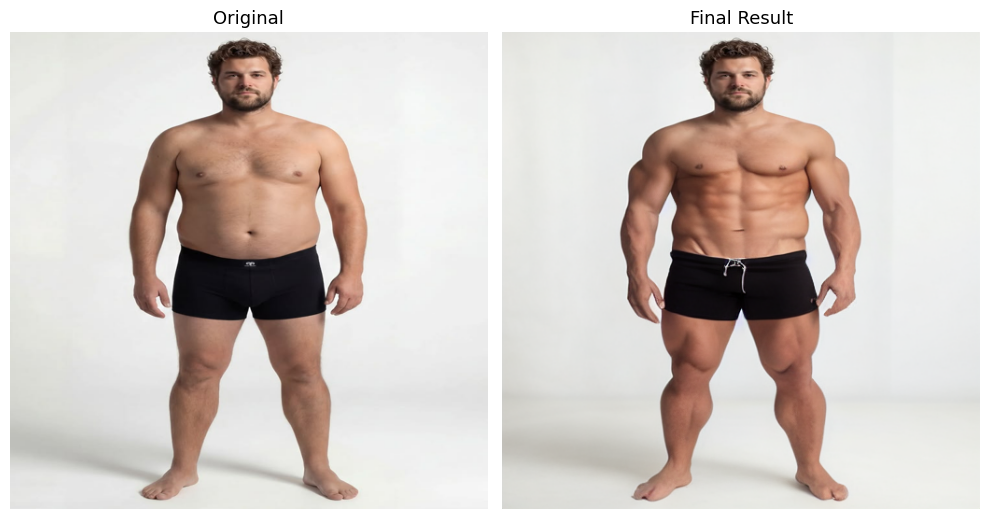

In [11]:
uploaded   = files.upload()
image_path = list(uploaded.keys())[0]

results = transform_physique(image_path, use_inpaint=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 6))
titles = ["Original", "Final Result"]
images = [results["original"], results["final"]]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img)
    ax.set_title(title, fontsize=13)
    ax.axis("off")

plt.tight_layout()
plt.show()